In [17]:
import os
os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/access_token", "w") as f:
    f.write("KGAT_8d60142d7d8dae6e173f42b04fa8ba6c")
os.chmod("/root/.kaggle/access_token", 0o600)

In [3]:
!pip install kagglehub -q
import kagglehub
path = kagglehub.dataset_download("samuelotiattakorah/agriculture-crop-yield")
print(path)

Using Colab cache for faster access to the 'agriculture-crop-yield' dataset.
/kaggle/input/agriculture-crop-yield


In [4]:
import pandas as pd, os

csv_file = [f for f in os.listdir(path) if f.endswith(".csv")][0]
df = pd.read_csv(os.path.join(path, csv_file))
df.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


In [5]:
df.info()          # shows column types and if any values are missing
df.isna().sum()     # counts missing values per column
df.describe()       # min/max/average for numeric columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Region                  1000000 non-null  object 
 1   Soil_Type               1000000 non-null  object 
 2   Crop                    1000000 non-null  object 
 3   Rainfall_mm             1000000 non-null  float64
 4   Temperature_Celsius     1000000 non-null  float64
 5   Fertilizer_Used         1000000 non-null  bool   
 6   Irrigation_Used         1000000 non-null  bool   
 7   Weather_Condition       1000000 non-null  object 
 8   Days_to_Harvest         1000000 non-null  int64  
 9   Yield_tons_per_hectare  1000000 non-null  float64
dtypes: bool(2), float64(3), int64(1), object(4)
memory usage: 62.9+ MB


,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,549.981901,27.504965,104.495025,4.649472
std,259.851320,7.220608,25.953412,1.696572
min,100.000896,15.000034,60.000000,-1.147613
25%,324.891090,21.254502,82.000000,3.417637
50%,550.124061,27.507365,104.000000,4.651808
75%,774.738520,33.753267,127.000000,5.879200
max,999.998098,39.999997,149.000000,9.963372


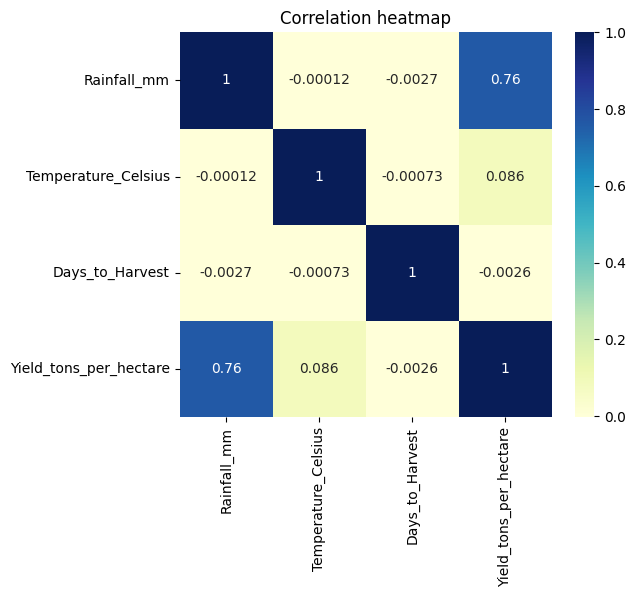

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ["Rainfall_mm", "Temperature_Celsius", "Days_to_Harvest", "Yield_tons_per_hectare"]
plt.figure(figsize=(6,5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="YlGnBu")
plt.title("Correlation heatmap")
plt.show()

The correlation heatmap shows that Rainfall_mm has by far the strongest correlation with yield (0.76), meaning higher rainfall is strongly associated with higher crop yield. Days_to_Harvest has the weakest correlation (-0.0026), essentially no linear relationship with yield, and Temperature_Celsius is also weak (0.086). This suggests rainfall will likely carry the most predictive weight in the model, while days-to-harvest alone tells us very little.

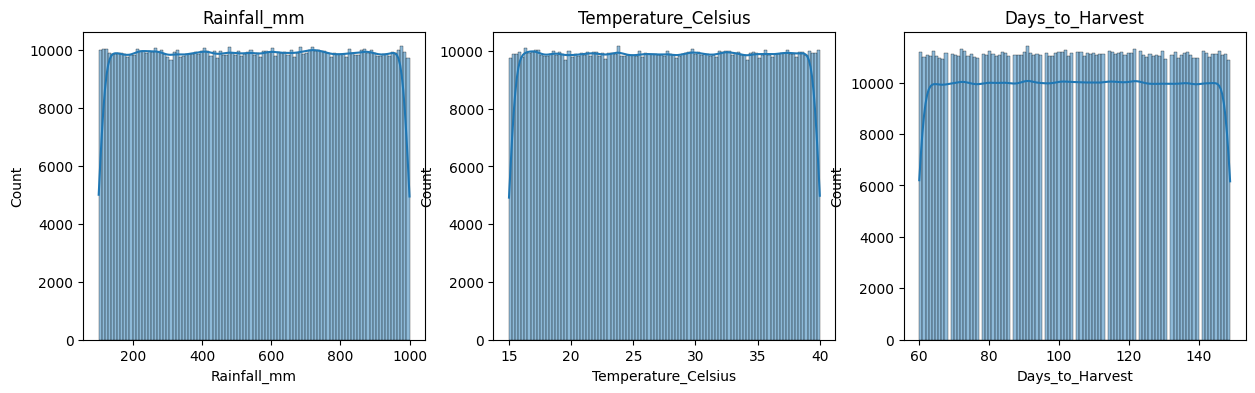

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, ["Rainfall_mm","Temperature_Celsius","Days_to_Harvest"]):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.show()

In [8]:
# booleans -> 0/1
df["Fertilizer_Used"] = df["Fertilizer_Used"].astype(int)
df["Irrigation_Used"] = df["Irrigation_Used"].astype(int)

# categories -> one-hot columns (e.g. Soil_Type becomes Soil_Type_Sandy, Soil_Type_Clay, etc.)
cat_cols = ["Region", "Soil_Type", "Crop", "Weather_Condition"]
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

target = "Yield_tons_per_hectare"
feature_cols = [c for c in df_encoded.columns if c != target]
X = df_encoded[feature_cols]
y = df_encoded[target]

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

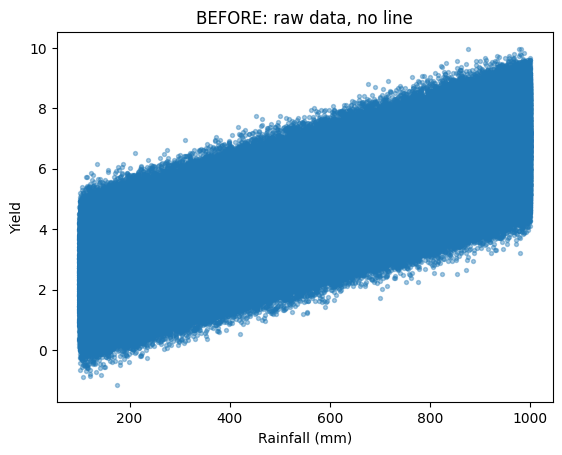

In [10]:
plt.scatter(df["Rainfall_mm"], df["Yield_tons_per_hectare"], s=8, alpha=0.4)
plt.xlabel("Rainfall (mm)"); plt.ylabel("Yield")
plt.title("BEFORE: raw data, no line")
plt.show()

In [11]:
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

results = {}
models = {}

# 1. Ordinary Linear Regression
lr = LinearRegression().fit(X_train_scaled, y_train)
pred = lr.predict(X_test_scaled)
results["Linear Regression"] = {"MSE": mean_squared_error(y_test, pred), "R2": r2_score(y_test, pred)}
models["Linear Regression"] = lr

# 2. SGDRegressor = the "stochastic" linear regression using gradient descent
sgd = SGDRegressor(max_iter=1, learning_rate="invscaling", eta0=0.01, random_state=42, warm_start=True)
train_losses, test_losses = [], []
for epoch in range(60):
    sgd.partial_fit(X_train_scaled, y_train)
    train_losses.append(mean_squared_error(y_train, sgd.predict(X_train_scaled)))
    test_losses.append(mean_squared_error(y_test, sgd.predict(X_test_scaled)))
pred = sgd.predict(X_test_scaled)
results["SGD Regressor"] = {"MSE": mean_squared_error(y_test, pred), "R2": r2_score(y_test, pred)}
models["SGD Regressor"] = sgd

# 3. Decision Tree
dt = DecisionTreeRegressor(max_depth=8, random_state=42).fit(X_train_scaled, y_train)
pred = dt.predict(X_test_scaled)
results["Decision Tree"] = {"MSE": mean_squared_error(y_test, pred), "R2": r2_score(y_test, pred)}
models["Decision Tree"] = dt

# 4. Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1).fit(X_train_scaled, y_train)
pred = rf.predict(X_test_scaled)
results["Random Forest"] = {"MSE": mean_squared_error(y_test, pred), "R2": r2_score(y_test, pred)}
models["Random Forest"] = rf

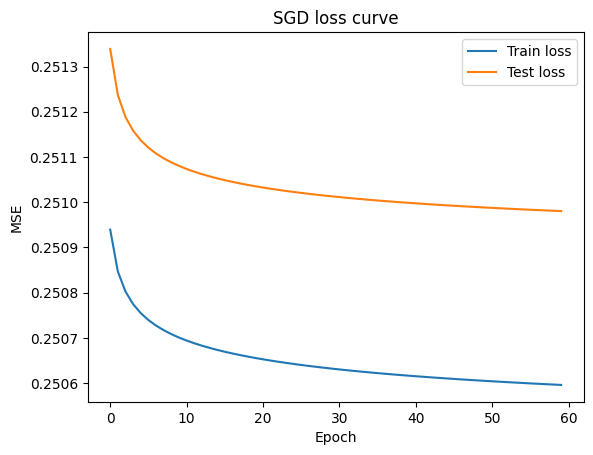

In [12]:
plt.plot(train_losses, label="Train loss")
plt.plot(test_losses, label="Test loss")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.legend()
plt.title("SGD loss curve")
plt.show()

In [13]:
results_df = pd.DataFrame(results).T.sort_values("MSE")
print(results_df)

best_name = results_df.index[0]
best_model = models[best_name]
print("Best model:", best_name)

                        MSE        R2
Linear Regression  0.250777  0.913014
SGD Regressor      0.250980  0.912943
Random Forest      0.252031  0.912579
Decision Tree      0.258030  0.910498
Best model: Linear Regression


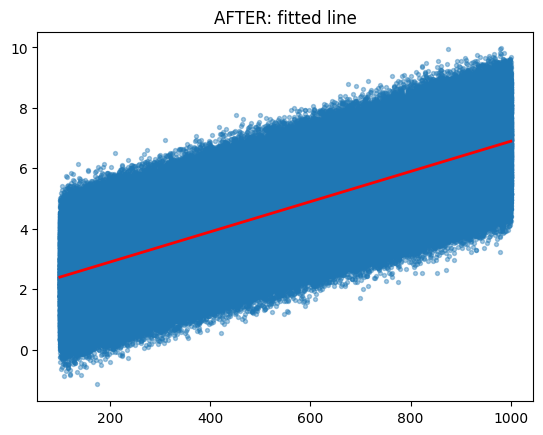

In [14]:
import numpy as np
from sklearn.linear_model import LinearRegression as LR1

x1 = df[["Rainfall_mm"]].values
y1 = df["Yield_tons_per_hectare"].values
line_model = LR1().fit(x1, y1)

x_line = np.linspace(x1.min(), x1.max(), 200).reshape(-1,1)
y_line = line_model.predict(x_line)

plt.scatter(x1, y1, s=8, alpha=0.4)
plt.plot(x_line, y_line, color="red", linewidth=2)
plt.title("AFTER: fitted line")
plt.show()

In [15]:
import joblib
joblib.dump(best_model, "best_model.joblib")
joblib.dump(scaler, "scaler.joblib")
joblib.dump(feature_cols, "feature_cols.joblib")

from google.colab import files
files.download("best_model.joblib")
files.download("scaler.joblib")
files.download("feature_cols.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
def predict_yield(raw_input: dict):
    row = pd.DataFrame([raw_input])
    row["Fertilizer_Used"] = row["Fertilizer_Used"].astype(int)
    row["Irrigation_Used"] = row["Irrigation_Used"].astype(int)
    row = pd.get_dummies(row, columns=["Region","Soil_Type","Crop","Weather_Condition"])
    row = row.reindex(columns=feature_cols, fill_value=0)
    row_scaled = scaler.transform(row)
    return float(best_model.predict(row_scaled)[0])

# test it
predict_yield({
    "Region": "North", "Soil_Type": "Loam", "Crop": "Wheat",
    "Rainfall_mm": 600, "Temperature_Celsius": 25,
    "Fertilizer_Used": True, "Irrigation_Used": True,
    "Weather_Condition": "Sunny", "Days_to_Harvest": 120
})

6.196936308869779